# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [76]:
df = pd.read_csv('Preprocessed_DonorsChoose_dataset.csv')

In [78]:
df.head()

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0
2,p182444,ms,az,grades_6_8,health_sports,health_wellness_teamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0
3,p246581,mrs,ky,grades_prek_2,literacy_language_math_science,literacy_mathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0
4,p104768,mrs,tx,grades_prek_2,math_science,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0


In [80]:
df.shape

(109248, 14)

# Data Preprocessing

In [83]:
print(df.columns)

Index(['id', 'teacher_prefix', 'school_state', 'project_grade_category',
       'project_subject_categories', 'project_subject_subcategories',
       'teacher_number_of_previously_posted_projects', 'project_is_approved',
       'price', 'quantity', 'cleaned_titles', 'cleaned_essays',
       'cleaned_summary', 'isdigit_summary'],
      dtype='object')


In [85]:
df = df.drop(columns=['id','cleaned_titles','cleaned_essays','cleaned_summary'])

In [87]:
print(df.shape)
print(df.columns)

(109248, 10)
Index(['teacher_prefix', 'school_state', 'project_grade_category',
       'project_subject_categories', 'project_subject_subcategories',
       'teacher_number_of_previously_posted_projects', 'project_is_approved',
       'price', 'quantity', 'isdigit_summary'],
      dtype='object')


In [89]:
categorical_cols = [
    'teacher_prefix',
    'school_state',
    'project_grade_category',
    'project_subject_categories',
    'project_subject_subcategories'
]

In [93]:
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

# Data Visualization

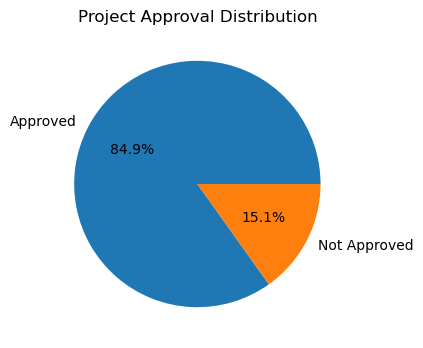

In [198]:
approval_counts = df['project_is_approved'].value_counts()

plt.figure(figsize=(6,4))
plt.pie(
    approval_counts,
    labels=['Approved','Not Approved'],
    autopct='%1.1f%%'
)

plt.title('Project Approval Distribution')
plt.savefig('approval_distribution.png')
plt.show()

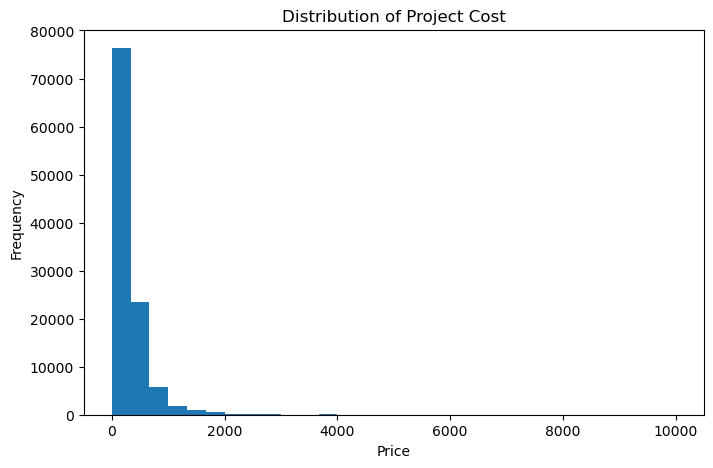

In [200]:
plt.figure(figsize=(8,5))

plt.hist(df['price'], bins=30)

plt.title('Distribution of Project Cost')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.savefig('price_distribution.png')
plt.show()

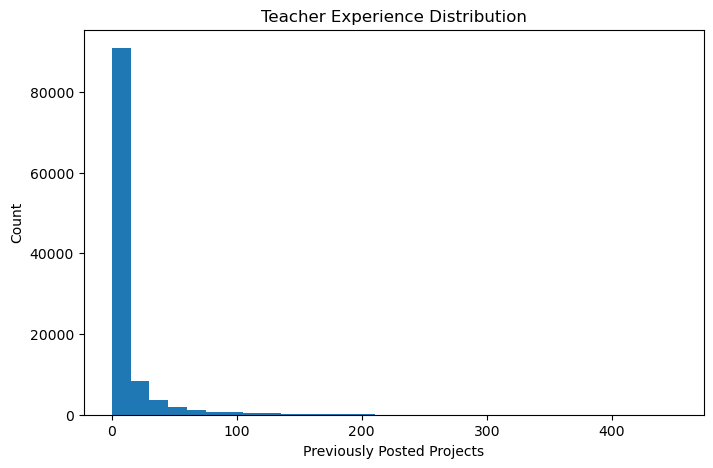

In [202]:
plt.figure(figsize=(8,5))

plt.hist(
    df['teacher_number_of_previously_posted_projects'],
    bins=30
)

plt.title('Teacher Experience Distribution')
plt.xlabel('Previously Posted Projects')
plt.ylabel('Count')
plt.savefig('teachers_experience.png')
plt.show()

# Model 1: Logistic Regression

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [98]:
X = df.drop('project_is_approved', axis = 1)
y = df['project_is_approved']

In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [102]:
print(X_train.shape)
print(X_test.shape)

(87398, 511)
(21850, 511)


In [104]:
lr = LogisticRegression(max_iter=1000) #max_iter used because the dataset is large

lr.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [105]:
y_pred = lr.predict(X_test)

In [106]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8476430205949657


In [110]:
print(confusion_matrix(y_test, y_pred))

[[   11  3305]
 [   24 18510]]


In [112]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.31      0.00      0.01      3316
           1       0.85      1.00      0.92     18534

    accuracy                           0.85     21850
   macro avg       0.58      0.50      0.46     21850
weighted avg       0.77      0.85      0.78     21850



# Model 2: Random Forest

In [117]:
from sklearn.ensemble import RandomForestClassifier

In [119]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [121]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [123]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [124]:
y_pred_rf = rf.predict(X_test)

In [127]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.8431121281464531


In [129]:
print(confusion_matrix(
    y_test,
    y_pred_rf
))

[[   83  3233]
 [  195 18339]]


In [131]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.30      0.03      0.05      3316
           1       0.85      0.99      0.91     18534

    accuracy                           0.84     21850
   macro avg       0.57      0.51      0.48     21850
weighted avg       0.77      0.84      0.78     21850



In [134]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

In [136]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [138]:
print(feature_importance.head(10))

                                         Feature  Importance
1                                          price    0.212163
2                                       quantity    0.162545
0   teacher_number_of_previously_posted_projects    0.117236
60          project_grade_category_grades_prek_2    0.024949
58             project_grade_category_grades_6_8    0.015864
11                               school_state_ca    0.014348
6                              teacher_prefix_ms    0.014263
5                             teacher_prefix_mrs    0.013327
59            project_grade_category_grades_9_12    0.011792
3                                isdigit_summary    0.009796


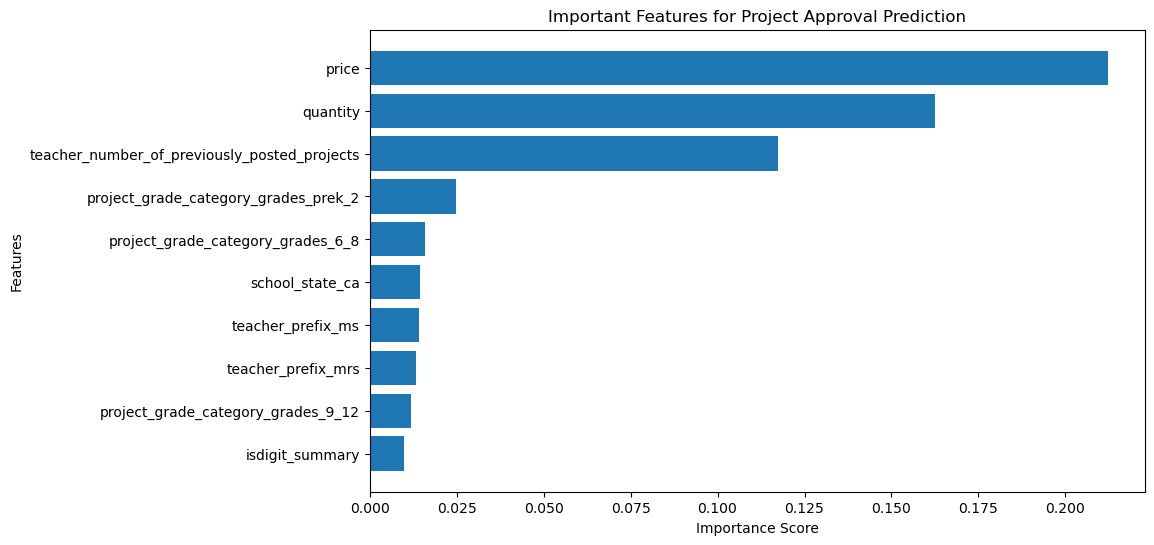

In [204]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Important Features for Project Approval Prediction')

plt.gca().invert_yaxis()
plt.savefig('feature_importance.png')
plt.show()

# Model 3: XGBoost

In [142]:
!pip install xgboost

In [144]:
from xgboost import XGBClassifier

In [146]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

In [148]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [154]:
y_pred_xgb = xgb.predict(X_test)

In [168]:
accuracy_xgb = accuracy_score(y_test,y_pred_xgb)

print("XGBoost Accuracy:", accuracy_xgb)

XGBoost Accuracy: 0.8482837528604119


In [170]:
print(confusion_matrix(y_test,y_pred_xgb))

[[   15  3301]
 [   14 18520]]


In [172]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.52      0.00      0.01      3316
           1       0.85      1.00      0.92     18534

    accuracy                           0.85     21850
   macro avg       0.68      0.50      0.46     21850
weighted avg       0.80      0.85      0.78     21850



In [174]:
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_xgb.head(10))

                                               Feature  Importance
84        project_subject_categories_literacy_language    0.019853
2                                             quantity    0.015193
427             project_subject_subcategories_literacy    0.014898
1                                                price    0.014600
3                                      isdigit_summary    0.014376
275  project_subject_subcategories_environmentalsci...    0.011940
0         teacher_number_of_previously_posted_projects    0.011298
110      project_subject_categories_warmth_care_hunger    0.011168
85   project_subject_categories_literacy_language_a...    0.011054
92             project_subject_categories_math_science    0.010516


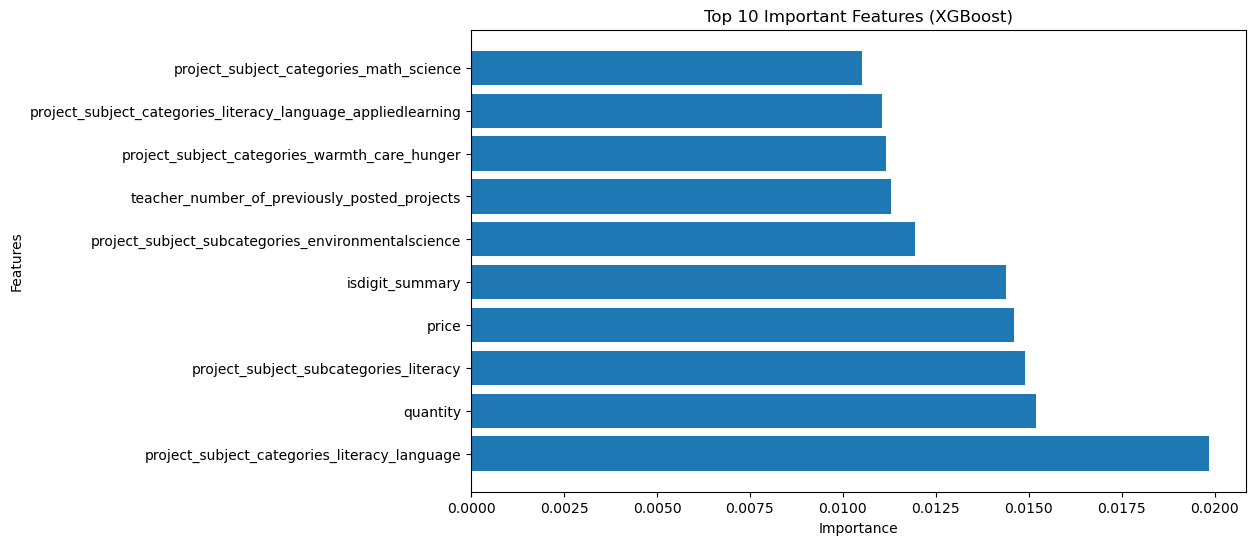

In [176]:
top10 = feature_importance_xgb.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features (XGBoost)")

plt.show()

# Model Comparison

In [178]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy,
        accuracy_rf,
        accuracy_xgb
    ]
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.847643
1        Random Forest  0.843112
2              XGBoost  0.848284


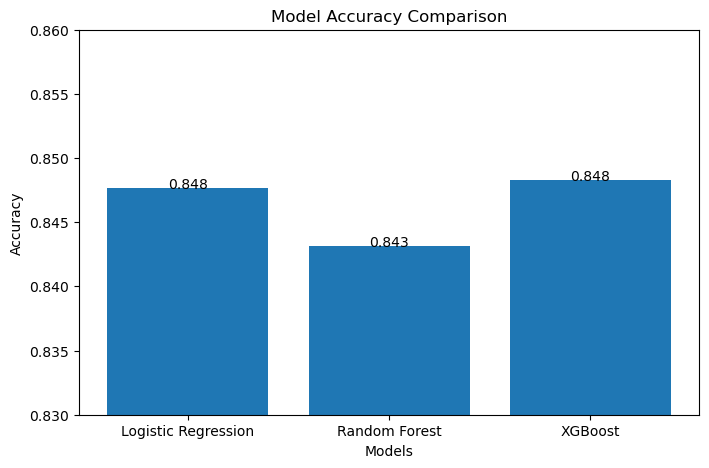

In [208]:
models = [
    'Logistic Regression',
    'Random Forest',
    'XGBoost'
]

accuracies = [
    accuracy,
    accuracy_rf,
    accuracy_xgb
]

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies)

plt.ylabel('Accuracy')
plt.xlabel('Models')
plt.title('Model Accuracy Comparison')

# Show values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.3f}',
        ha='center'
    )

plt.ylim(0.83,0.86)
plt.savefig('model_comparison.png')
plt.show()